In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')

In [3]:
df.head()


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
df.shape

(439140, 16)

In [5]:
df.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='object')

In [6]:
df.describe()


,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [7]:
df.isnull().sum()

,0
id,0
Driver,0
Compound,0
Race,0
Year,0
PitStop,0
LapNumber,0
Stint,0
TyreLife,0
Position,0


In [8]:
df[df.duplicated()]


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["PitNextLap"].value_counts(normalize=True)
#This tells you: Data is imbalanced
#Model might bias toward predicting 0
#Accuracy can be misleading

,proportion
PitNextLap,
0.0,0.801018
1.0,0.198982


In [11]:
df.groupby("TyreLife")["PitNextLap"].mean()

,PitNextLap
TyreLife,
1.0,0.004881
2.0,0.031796
3.0,0.046363
4.0,0.078435
5.0,0.087391
...,...
73.0,0.100000
74.0,0.444444
75.0,0.125000


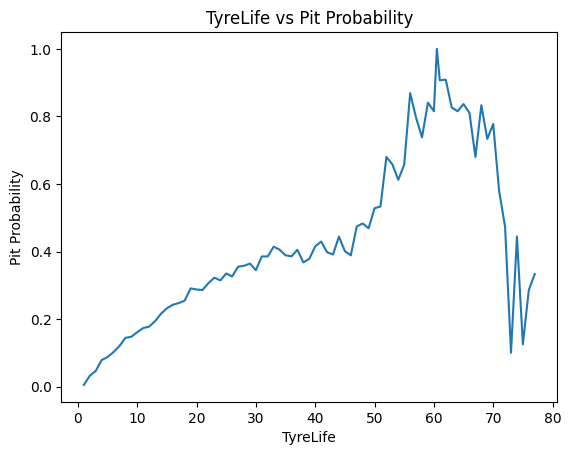

In [12]:

df.groupby("TyreLife")["PitNextLap"].mean().plot()

plt.xlabel("TyreLife")
plt.ylabel("Pit Probability")
plt.title("TyreLife vs Pit Probability")
plt.show()

In [13]:
df.corr(numeric_only=True)["PitNextLap"].sort_values(ascending=False)
#Using this to know if its  > 0.8, then they are maybe linearaly correlated
#if <0.8 , they could be non-linear or conditional

,PitNextLap
PitNextLap,1.000000
TyreLife,0.273510
LapNumber,0.267057
Stint,0.198193
RaceProgress,0.185477
Year,0.125267
PitStop,0.048567
Position_Change,0.046230
Position,0.021348
id,-0.000097


In [14]:
df = df.drop(columns=["id"])

In [15]:
df.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [16]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Features
features = [
    "TyreLife",
    "Cumulative_Degradation",
    "LapTime_Delta",
    "LapNumber",
    "Stint",
    "RaceProgress",
    "Position",
    "Position_Change",
    "Year"
]

# One-hot encode Compound
X = pd.get_dummies(df[features + ["Compound"]], drop_first=True)
y = df["PitNextLap"]


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [18]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict_proba(X_test)[:, 1]

# AUC
print("AUC:", roc_auc_score(y_test, y_pred))

AUC: 0.9340042392953334


In [19]:
importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(feature_importance_df.head(10))

#Here Year has the highest importance but that can be possible, this is data leakage. Now remove Year and do
#it again

                  feature  importance
8                    Year    0.304586
4                   Stint    0.192984
10        Compound_MEDIUM    0.102651
11          Compound_SOFT    0.099171
0                TyreLife    0.076928
3               LapNumber    0.060000
2           LapTime_Delta    0.047314
5            RaceProgress    0.034426
9   Compound_INTERMEDIATE    0.025051
7         Position_Change    0.020690


In [20]:
features = [
    "TyreLife",
    "Cumulative_Degradation",
    "LapTime_Delta",
    "LapNumber",
    "Stint",
    "RaceProgress",
    "Position",
    "Position_Change"
]

X = pd.get_dummies(df[features + ["Compound"]], drop_first=True)
y = df["PitNextLap"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [21]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42
)
model.fit(X_train, y_train)

# Predict probabilities
y_pred = model.predict_proba(X_test)[:, 1]

# AUC score
auc = roc_auc_score(y_test, y_pred)
print("AUC:", auc)

#Even though accuracy has dropped its more reliable now

AUC: 0.9260598344953541


In [22]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df.head(10))

                   feature  importance
4                    Stint    0.256925
2            LapTime_Delta    0.154707
9          Compound_MEDIUM    0.120106
0                 TyreLife    0.095164
10           Compound_SOFT    0.094037
3                LapNumber    0.086150
7          Position_Change    0.069063
5             RaceProgress    0.049122
8    Compound_INTERMEDIATE    0.023522
1   Cumulative_Degradation    0.021224


In [23]:
model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [24]:
features = [
    "TyreLife",
    "Cumulative_Degradation",
    "LapTime_Delta",
    "LapNumber",
    "Stint",
    "RaceProgress",
    "Position",
    "Position_Change"

]

X_test_final = pd.get_dummies(df_test[features + ["Compound"]], drop_first=True)
X, X_test_final = X.align(X_test_final, join="left", axis=1, fill_value=0)
y_test_pred = model.predict_proba(X_test_final)[:, 1]

In [25]:
submission = pd.DataFrame({
    "id": df_test["id"],
    "PitNextLap": y_test_pred
})

submission.to_csv("submission.csv", index=False)

In [26]:
import pickle
with open('f1pitstops.pkl', 'wb') as file:
    pickle.dump(model, file)